#EVALUACION 1 : red de distribucion
#Descripcion: encuentra la ruta optima y valida si el despacho esta autorizado
#Situacion: una empresa de logistica debe despachar mercancia desde un centro principal (CP) hacia 5 puntos de entrega, pasando por almacenes intermedios

In [20]:
import matplotlib.pyplot as plt  # Librerias para graficar
import networkx as nx            # librerias que me permite trabajar con estructuras complejas como grafos
import heapq                     # cola de prioridad para el algoritmo de costo uniforme
from collections import deque    # cola para el algoritmo de anchura

In [21]:
# Creamos una instancia con la clase DiGraph (grafo dirigido y ponderado)
grafo = nx.DiGraph()

In [22]:
# Creamos el grafo utilizando el metodo add_edge, con peso (km) y capacidad_maxima (toneladas)
tramos = [
    ("CP", "A1", 12, 30),
    ("CP", "A2", 9, 25),
    ("CP", "A3", 15, 40),
    ("A1", "A2", 5, 15),
    ("A2", "A3", 6, 20),
    ("A1", "E1", 8, 20),
    ("A1", "E2", 14, 15),
    ("A2", "E2", 7, 18),
    ("A2", "E3", 10, 22),
    ("A2", "E4", 16, 12),
    ("A3", "E3", 4, 25),
    ("A3", "E4", 9, 30),
    ("A3", "E5", 13, 20),
    ("E4", "E5", 5, 10),
]
for origen, destino, peso, capacidad in tramos:
    grafo.add_edge(origen, destino, peso=peso, capacidad_maxima=capacidad)

entregas = ["E1", "E2", "E3", "E4", "E5"]

In [23]:
# posiciones de los nodos para dibujar
pos = {
    "CP": (0, 0),
    "A1": (2, 2), "A2": (2, 0), "A3": (2, -2),
    "E1": (4, 3), "E2": (4, 1.2), "E3": (4, -0.4), "E4": (4, -1.8), "E5": (4, -3.2),
}

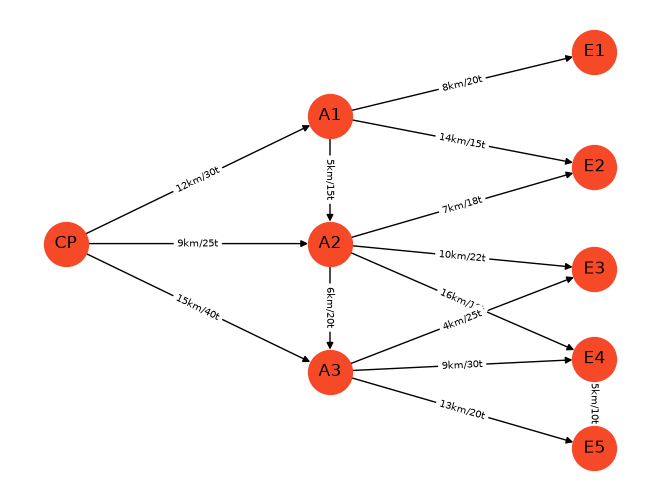

In [24]:
# mostrar el grafo
nx.draw(
    grafo,
    pos,
    with_labels=True,
    node_size=1000,
    node_color="#F54927",
    node_shape="o",
    arrows=True,
)
labels = {(u, v): f"{d['peso']}km/{d['capacidad_maxima']}t" for u, v, d in grafo.edges(data=True)}
nx.draw_networkx_edge_labels(grafo, pos, edge_labels=labels, font_size=7)
plt.show()

#PARTE B: logica proposicional
#P: el vehiculo tiene mantenimiento preventivo al dia
#Q: la carga no excede la capacidad limite de la ruta
#R: las condiciones climaticas son favorables
#S: ruta autorizada para despacho
#Regla: (P y Q y R) => S

In [25]:
# dejamos solo los tramos que soportan la carga
def tramos_validos(g, carga):
    h = nx.DiGraph()
    h.add_nodes_from(g.nodes)
    for u, v, d in g.edges(data=True):
        if d["capacidad_maxima"] >= carga:
            h.add_edge(u, v, **d)
    return h

In [26]:
# evaluamos P, Q, R y la regla (P y Q y R) => S
def autorizacion(g, origen, destino, carga, mantenimiento, clima):
    P = mantenimiento
    Q = nx.has_path(tramos_validos(g, carga), origen, destino)
    R = clima
    S = P and Q and R
    return P, Q, R, S

In [27]:
# tabla de verdad de la regla
from itertools import product

print("P      Q      R      S")
for P, Q, R in product([True, False], repeat=3):
    S = P and Q and R
    print(f"{str(P):<7}{str(Q):<7}{str(R):<7}{S}")

P      Q      R      S
True   True   True   True
True   True   False  False
True   False  True   False
True   False  False  False
False  True   True   False
False  True   False  False
False  False  True   False
False  False  False  False


#PARTE C: busqueda en anchura (BFS) y costo uniforme (UCS)
#BFS: encuentra el camino con menos tramos, no considera el peso
#UCS: encuentra el camino de menor costo total (km)

In [28]:
# calculamos el costo de una ruta
def costo_ruta(g, ruta):
    costo = 0
    for i in range(len(ruta) - 1):
        costo += g[ruta[i]][ruta[i + 1]]["peso"]
    return costo

In [29]:
# busqueda en anchura (BFS)
def bfs(g, origen, destino):
    frontera = deque([[origen]])
    en_frontera = {origen}
    visitados = []
    while frontera:
        camino = frontera.popleft()
        nodo = camino[-1]
        visitados.append(nodo)
        if nodo == destino:
            return camino, costo_ruta(g, camino), visitados
        for vecino in g.successors(nodo):
            if vecino not in en_frontera:
                en_frontera.add(vecino)
                frontera.append(camino + [vecino])
    return None, float("inf"), visitados

In [30]:
# busqueda de costo uniforme (UCS)
def ucs(g, origen, destino):
    frontera = [(0, origen, [origen])]
    expandidos = set()
    visitados = []
    while frontera:
        costo, nodo, camino = heapq.heappop(frontera)
        if nodo in expandidos:
            continue
        expandidos.add(nodo)
        visitados.append(nodo)
        if nodo == destino:
            return camino, costo, visitados
        for vecino in g.successors(nodo):
            if vecino not in expandidos:
                heapq.heappush(frontera, (costo + g[nodo][vecino]["peso"], vecino, camino + [vecino]))
    return None, float("inf"), visitados

In [31]:
# sistema de despacho: si S es False se bloquea la busqueda
def despachar(origen, destino, carga, mantenimiento, clima):
    print(f"Despacho {origen} -> {destino} | carga: {carga} t")

    if origen not in grafo or destino not in grafo:
        print("El origen o el destino no existe\n")
        return
    if origen == destino:
        print("Origen y destino son el mismo nodo\n")
        return

    P, Q, R, S = autorizacion(grafo, origen, destino, carga, mantenimiento, clima)
    print(f"P={P}  Q={Q}  R={R}  S={S}")

    if not S:
        print("Busqueda bloqueada\n")
        return

    h = tramos_validos(grafo, carga)
    for nombre, algoritmo in [("BFS", bfs), ("UCS", ucs)]:
        camino, costo, visitados = algoritmo(h, origen, destino)
        print(f"{nombre}: {camino} -> {costo} km, nodos visitados: {len(visitados)} {visitados}")

    camino, costo, visitados = ucs(h, origen, destino)
    print(f"El camino optimo es: {camino} con {costo} km\n")

    nx.draw(grafo, pos, with_labels=True, node_size=1000, node_color="#F54927", node_shape="o", arrows=True)
    nx.draw_networkx_edges(grafo, pos, edgelist=list(zip(camino, camino[1:])), edge_color="blue", width=3)
    nx.draw_networkx_edge_labels(grafo, pos, edge_labels=labels, font_size=7)
    plt.show()

#Caso 1: despacho autorizado

Despacho CP -> E4 | carga: 15 t
P=True  Q=True  R=True  S=True
BFS: ['CP', 'A3', 'E4'] -> 24 km, nodos visitados: 8 ['CP', 'A1', 'A2', 'A3', 'E1', 'E2', 'E3', 'E4']
UCS: ['CP', 'A2', 'A3', 'E4'] -> 24 km, nodos visitados: 8 ['CP', 'A2', 'A1', 'A3', 'E2', 'E3', 'E1', 'E4']
El camino optimo es: ['CP', 'A2', 'A3', 'E4'] con 24 km



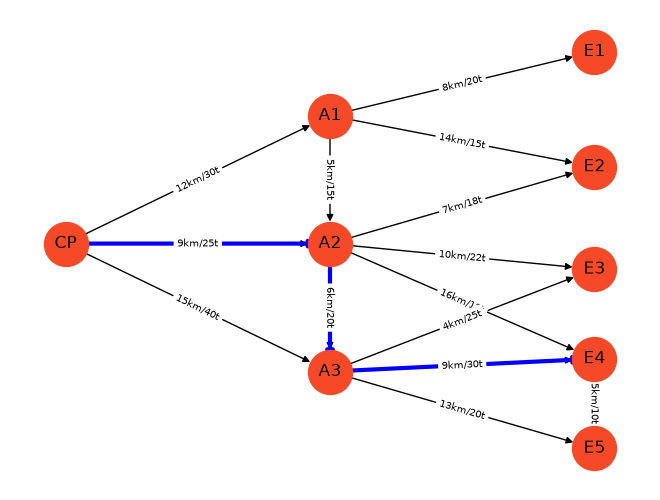

In [34]:
despachar("CP", "E4", 15, True, True)

#Caso 2: bloqueado por mantenimiento vencido (P = False)

In [35]:
despachar("CP", "E3", 10, False, True)

Despacho CP -> E3 | carga: 10 t
P=False  Q=True  R=True  S=False
Busqueda bloqueada



#Caso 3: bloqueado por clima desfavorable (R = False)

In [36]:
despachar("CP", "E1", 10, True, False)

Despacho CP -> E1 | carga: 10 t
P=True  Q=True  R=False  S=False
Busqueda bloqueada



#Caso 4: bloqueado por sobrecarga (Q = False)

In [37]:
despachar("CP", "E1", 26, True, True)

Despacho CP -> E1 | carga: 26 t
P=True  Q=False  R=True  S=False
Busqueda bloqueada



#Caso 5: con 20 t se descartan tramos, cambia la ruta optima

Despacho CP -> E4 | carga: 20 t
P=True  Q=True  R=True  S=True
BFS: ['CP', 'A3', 'E4'] -> 24 km, nodos visitados: 7 ['CP', 'A1', 'A2', 'A3', 'E1', 'E3', 'E4']
UCS: ['CP', 'A2', 'A3', 'E4'] -> 24 km, nodos visitados: 7 ['CP', 'A2', 'A1', 'A3', 'E3', 'E1', 'E4']
El camino optimo es: ['CP', 'A2', 'A3', 'E4'] con 24 km



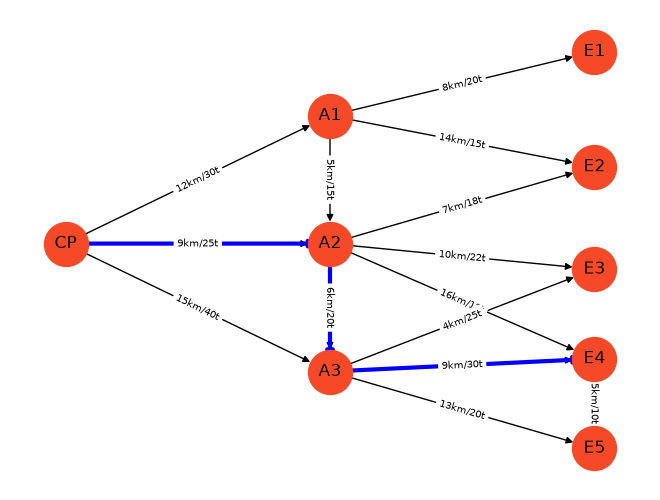

In [38]:
despachar("CP", "E4", 20, True, True)

#Casos limite: nodo inexistente y origen igual a destino

In [39]:
despachar("CP", "E9", 10, True, True)
despachar("CP", "CP", 10, True, True)

Despacho CP -> E9 | carga: 10 t
El origen o el destino no existe

Despacho CP -> CP | carga: 10 t
Origen y destino son el mismo nodo



#Comparacion de BFS y UCS hacia todas las entregas (carga de 10 t)

In [40]:
total_bfs = 0
total_ucs = 0
for e in entregas:
    cb, kb, vb = bfs(grafo, "CP", e)
    cu, ku, vu = ucs(grafo, "CP", e)
    total_bfs += kb
    total_ucs += ku
    print(f"{e}: BFS {cb} {kb}km ({len(vb)} nodos) | UCS {cu} {ku}km ({len(vu)} nodos)")

print(f"Total BFS: {total_bfs} km | Total UCS: {total_ucs} km")

# Relacion con la busqueda en IA:
# El centro de distribucion representa un agente inteligente que debe recorrer una red
# modelada como grafo dirigido y ponderado. BFS explora por niveles y solo es optimo
# cuando todos los tramos cuestan lo mismo, mientras que UCS expande siempre el nodo
# de menor costo acumulado y por eso encuentra el camino mas corto en kilometros.
# La regla (P y Q y R) => S funciona como filtro previo a la busqueda: evita explorar
# el espacio de estados cuando el despacho no es viable por mantenimiento, capacidad o clima.

E1: BFS ['CP', 'A1', 'E1'] 20km (5 nodos) | UCS ['CP', 'A1', 'E1'] 20km (7 nodos)
E2: BFS ['CP', 'A1', 'E2'] 26km (6 nodos) | UCS ['CP', 'A2', 'E2'] 16km (5 nodos)
E3: BFS ['CP', 'A2', 'E3'] 19km (7 nodos) | UCS ['CP', 'A2', 'A3', 'E3'] 19km (6 nodos)
E4: BFS ['CP', 'A2', 'E4'] 25km (8 nodos) | UCS ['CP', 'A2', 'A3', 'E4'] 24km (8 nodos)
E5: BFS ['CP', 'A3', 'E5'] 28km (9 nodos) | UCS ['CP', 'A2', 'A3', 'E5'] 28km (9 nodos)
Total BFS: 118 km | Total UCS: 107 km
